In [2]:
from langgraph.graph import START, END, StateGraph, MessagesState
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, BaseMessage, RemoveMessage
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

In [3]:
class State(MessagesState):
    summary:str

In [5]:
chat = ChatGroq(
    model="qwen/qwen3.6-27b"
)

In [6]:
def ask(state=State)-> State:
    print("*"*10)
    print("\n-------> Entering the ask state")
    for i in state['messages']:
        i.pretty_print()
    question = "What is your Question ?"
    print(question)

    return State(messages=[AIMessage(question), HumanMessage(input())])    

In [7]:
def chatbot(state:State)-> State:
    print("\n--------------> Entering Chatbot:")
    response = chat.invoke(state['messages'])
    response.pretty_print()
    system_message = f'''
    Here is the Quick Summary of what has been discussed so far:
    {state.get("summary","")}

    Keep this in mind as you answer the next question.
    '''
    response = chat.invoke([SystemMessage(system_message)]+state["messages"])
    response.pretty_print()
    return State(messages = [response])

In [8]:
def summarise_messages(state:State) -> State:
    print(f"----------> Entering summarise_and_delete_messages:")

    new_conversation = ""
    for i in state["messages"]:
        new_conversation += f"{i.type}: {i.content}\n\n"

    summary_instructions = f"""
update the ongoing summary by incorporating the new lines of conversation below.
Build upon the previous summary rather than repeating it so that the result reflects
the most recent context and developments.

Previous Summary:
{state.get("summary","")}

New Conversation:
{new_conversation}
"""

    print(summary_instructions)
    summary = chat.invoke([HumanMessage(summary_instructions)])

    remove_messages = [RemoveMessage(id=i.id) for i in state["messages"][:-5]]
    return State(messages=remove_messages, summary=summary.content)

In [9]:
graph = StateGraph(State)

graph.add_node("ask", ask)
graph.add_node("chatbot", chatbot)
graph.add_node("summarise_messages", summarise_messages)

In [10]:
graph.add_edge(START, "ask")
graph.add_edge("ask", "chatbot")
graph.add_edge("chatbot", "summarise_messages")
graph.add_edge("summarise_messages", END)

In [11]:
db_path = "./database.db"
con = sqlite3.connect(database=db_path, check_same_thread=False)

In [12]:
checkpointer = SqliteSaver(con)
graph_compiled = graph.compile(checkpointer)

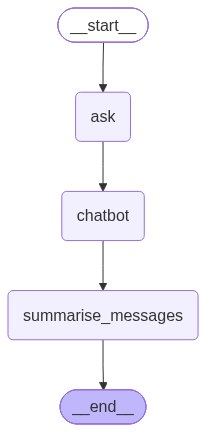

In [13]:
graph_compiled

In [14]:
config1 = {"configurable" : {"thread_id":"1"}}

In [16]:
graph_states = graph_compiled.invoke(State(),config1)

**********

-------> Entering the ask state
================================== Ai Message ==================================

What is your Question ?
================================ Human Message =================================

Who is the Prime Minister of India
================================== Ai Message ==================================


<think>
Here's a thinking process:

1.  **Analyze User Input:**
   - User asks: "Who is the Prime Minister of India"
   - This is a straightforward factual question about current leadership in India.

2.  **Identify Key Information Needed:**
   - Current Prime Minister of India
   - Need to ensure the information is up-to-date as of the current date (2026)

3.  **Check Knowledge Cutoff & Current Status:**
   - My knowledge cutoff is 2026.
   - As of my last update, Narendra Modi has been the Prime Minister of India since May 2014.
   - He was re-elected for a third term in June 2024.
   - There's no information suggesting a change in leadersh

In [17]:
graph_states

{'messages': [HumanMessage(content='Who is the Prime Minister of India', additional_kwargs={}, response_metadata={}, id='d7d61a02-280e-4d8c-848a-a06189f4d149'),
  AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - User asks: "Who is the Prime Minister of India"\n   - This is a straightforward factual question about current leadership in India.\n\n2.  **Identify Key Information Needed:**\n   - Current Prime Minister of India\n   - Need to ensure the information is up-to-date as of the current date (2026)\n\n3.  **Check Knowledge Cutoff & Current Status:**\n   - My knowledge cutoff is 2026.\n   - As of my last update, Narendra Modi has been the Prime Minister of India since May 2014.\n   - He was re-elected for a third term in June 2024.\n   - There\'s no information suggesting a change in leadership between 2024 and 2026.\n   - Therefore, as of 2026, Narendra Modi is still the Prime Minister of India.\n\n4.  **Formulate Response:**\n   - State